# Crossword Puzzle (Backtracking)

A Crossword grid is provided to you, along with a set of words (or names of places) which need to be filled into the grid. Cells are marked either `+` or `-`. Cells marked with a `-` are to be filled with the word list.

---

## Example

The following shows an example crossword from the input grid and the list of words to fit:

### Input

```
++++++++++
+------+++
+++-++++++
+++-++++++
+++-----++
+++-++-+++
++++++-+++
++++++-+++
++++++-+++
++++++++++
POLAND;LHASA;SPAIN;INDIA

++++++++++
+POLAND+++
+++H++++++
+++A++++++
+++SPAIN++
+++A++N+++
++++++D+++
++++++I+++
++++++A+++
++++++++++
```

---

## Function Description

Complete the `crosswordPuzzle` function in the editor below. It should return an array of strings, each representing a row of the finished puzzle.

### Parameters:
- `crossword`: a list of strings representing the empty grid
- `words`: a string of semicolon-separated words to fit into the grid

---

## Input Format

- The first 10 lines each contain a string of length 10 representing the crossword grid.
- The last line contains a semicolon-separated string of words.

---

## Constraints

- Grid size is fixed at 10x10
- Each word must be placed exactly once
- Words cannot be reversed
- `+` cells are blocked and cannot be modified
- `-` cells must be filled

---

## Output Format

Return the completed crossword grid as a list of strings.

---

## Sample Input 0

```
+-++++++++
+-++++++++
+-++++++++
+-----++++
+-+++-++++
+-+++-++++
+++++-++++
++------++
+++++-++++
+++++-++++
LONDON;DELHI;ICELAND;ANKARA
```


## Sample Output 0


```
+L++++++++
+O++++++++
+N++++++++
+DELHI++++
+O+++C++++
+N+++E++++
+++++L++++
++ANKARA++
+++++N++++
+++++D++++
```

## 🚀 0️⃣ Pattern Recognition

**Type:** Constraint Satisfaction Problem (CSP) + Backtracking

We are NOT traversing a grid (not graph DFS).
We are assigning **words to fixed slots (variables)** under constraints.

👉 Strategy: **Backtracking over slot assignments with pruning**

Why this wins:

* Grid structure is static
* Only decisions are “which word goes in which slot”
* Constraints prune early (mismatch = cut branch)

---s

# 1️⃣ Specification

## 🎯 Core

Fill a 10x10 crossword grid by assigning given words into precomputed horizontal/vertical slots such that all constraints (fixed letters and lengths) are satisfied.

---

## 🧩 Blueprint

```python
from typing import List, Tuple

class Solution:
    def crosswordPuzzle(self, grid: List[str], words: str) -> List[str]:
        pass


def extract_slots(grid: List[List[str]]) -> List[List[Tuple[int,int]]]:
    pass
```

---

## ⚠️ Edge Cases & Traps

1. Slot length mismatch with all words
2. Overlapping constraints forcing backtracking early
3. Multiple valid placements (non-unique solution space)
4. Words sharing same length (permutation explosion)
5. Grid fully open (`-` everywhere → worst-case factorial)

---

# 2️⃣ Plan

## 🧠 Strategy

We:

1. Extract all horizontal + vertical slots
2. Try assigning words to slots (permutation search)
3. Validate incremental constraints
4. Backtrack on conflict

Why not DFS grid traversal?

* Grid is NOT state space
* State is **(slot index → word assignment)**

---

## 🔍 Visual Trace

Slots:

```
S0 → [------]
S1 → [-----]
```

Words:

```
W1, W2, W3
```

Search tree:

```
S0 → W1 → S1 → W2 → ...
     ↘ W2
     ↘ W3
```

Backtracking happens on mismatch:

* letter conflict
* used word repetition
* length mismatch

---

---

# 4️⃣ Complexity

## ⏱ Time Complexity

Worst case:
[
O(W!)
]

Where:

* W = number of words / slots

Because we try permutations of word-slot assignments.

Pruning reduces this heavily in practice.

---

## 🧠 Space Complexity

[
O(S + R \cdot C)
]

* recursion stack: O(S)
* grid storage: O(100)
* slots: O(S)

---

## 💾 Optimization ideas

* Sort slots by constraint (minimum remaining values heuristic)
* Pre-index words by length
* Early pruning using letter frequency mismatch

---

# 🏷 Naming improvements

* `slot` → `segment`
* `used` → `used_words`
* `dfs` → `backtrack_assign`

---

# 🚀 Production readiness

To be production-grade:

* input validation (grid shape)
* logging of backtracking depth
* deterministic tie-breaking
* timeout guard (important for factorial search)
* optional caching of failed states (memoization of slot index + mask)

---

# 🎓 Final Insight

This problem is NOT grid traversal.

It is:

> **a constraint assignment problem over fixed structural variables (slots)**

Backtracking is just the search engine — not the model itself.


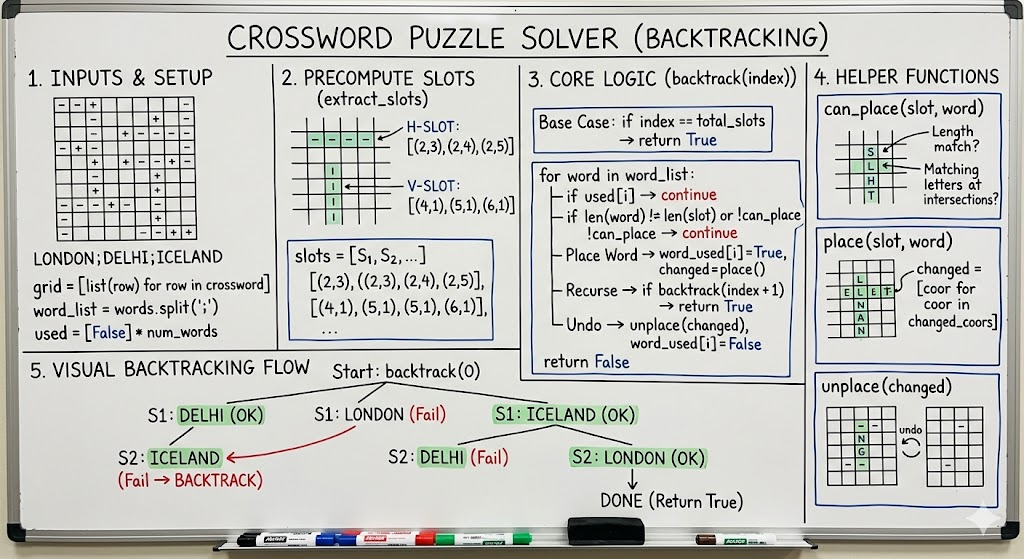

In [ ]:
#!/bin/python3

import math
import os
import random
import re
import sys
from typing import List, Tuple

ROWS, COLS = 10, 10


def crosswordPuzzle(crossword: List[str], words: str) -> List[str]:
    # Convert grid to mutable structure
    grid = [list(row) for row in crossword]
    word_list = words.split(";")
    total_words = len(word_list)
    # Precompute all horizontal and vertical slots
    slots = extract_slots(grid)
    total_slots = len(slots)
    
    # Track used words
    used = [False] *  total_words

    # ------------------------------------------------------------
    # Check if a word can be placed in a slot
    # ------------------------------------------------------------
    def can_place(slot: List[Tuple[int, int]], word: str) -> bool:
        for (r, c), char in zip(slot, word):
            # Either empty '-' or matching letter already placed
            if grid[r][c] != '-' and grid[r][c] != char:
                return False
        return True

    # ------------------------------------------------------------
    # Place word into grid and return modified positions
    # ------------------------------------------------------------
    def place(slot: List[Tuple[int, int]], word: str):
        changed = []
        for (r, c), char in zip(slot, word):
            if grid[r][c] == '-':
                grid[r][c] = char
                changed.append((r, c))
        return changed

    # ------------------------------------------------------------
    # Undo placement (backtracking step)
    # ------------------------------------------------------------
    def unplace(changed):
        for r, c in changed:
            grid[r][c] = '-'

    # ------------------------------------------------------------
    # Backtracking over slots
    # ------------------------------------------------------------
    def backtrack(index: int) -> bool:
        # All slots filled
        if index == total_slots:
            return True

        slot = slots[index]

        for i in range(total_words):
            if used[i]:
                continue

            word = word_list[i]

            # Skip if size mismatch
            if len(word) != len(slot) or not can_place(slot, word):
                continue
            # Try placing word
            used[i] = True
            changed = place(slot, word)
            # Recurse
            if backtrack(index + 1):
                return True
            # Backtrack
            unplace(changed)
            used[i] = False

        return False

    # Start DFS backtracking
    backtrack(0)

    # Convert back to required output format
    return ["".join(row) for row in grid]


# ------------------------------------------------------------
# Extract all horizontal and vertical slots
# ------------------------------------------------------------
def extract_slots(grid: List[List[str]]) -> List[List[Tuple[int, int]]]:
    slots = []

    # Horizontal slots
    for r in range(ROWS):
        c = 0
        while c < COLS:
            if grid[r][c] == '-':
                cells = []
                while c < COLS and grid[r][c] == '-':
                    cells.append((r, c))
                    c += 1
                if len(cells) > 1:
                    slots.append(cells)
            else:
                c += 1

    # Vertical slots
    for c in range(COLS):
        r = 0
        while r < ROWS:
            if grid[r][c] == '-':
                cells = []
                while r < ROWS and grid[r][c] == '-':
                    cells.append((r, c))
                    r += 1
                if len(cells) > 1:
                    slots.append(cells)
            else:
                r += 1

    return slots

if __name__ == '__main__':
    fptr = open(os.environ['OUTPUT_PATH'], 'w')

    crossword = []

    for _ in range(10):
        crossword_item = input()
        crossword.append(crossword_item)

    words = input()

    result = crosswordPuzzle(crossword, words)

    fptr.write('\n'.join(result))
    fptr.write('\n')

    fptr.close()
